# Bag of Words Meets Bags of Popcorn Sentiment Analysis

<img src='https://storage.googleapis.com/kaggle-datasets-images/12946/17630/cb50fd3b236d01184fd23ad59af50b4f/dataset-cover.jpg?t=2018-02-13-18-15-51'>

Bu projede, Word2Vec NLP Tutorial kapsamında verilen metin verileri kullanılarak bir doğal dil işleme (NLP) ve duygu analizi (sentiment analysis) problemi çözülmesi amaçlanmıştır. Amaç, metinlerdeki duygu bilgisini (pozitif/negatif) doğru şekilde tahmin edebilen modeller geliştirmek ve özellikle Word2Vec embedding yöntemini kullanarak derin öğrenme modellerinin performansını karşılaştırmaktır.

In this project, a natural language processing (NLP) and sentiment analysis task was performed using the dataset from the Word2Vec NLP Tutorial competition. The goal was to build models that can accurately classify text sentiment (positive/negative) and to compare different deep learning architectures using Word2Vec embeddings.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
#pip install gensim

In [3]:
# =======================
# Standard Libraries
# =======================
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

# =======================
# Data & Numerical
# =======================
import pandas as pd
import numpy as np

# =======================
# Visualization
# =======================
import matplotlib.pyplot as plt
import seaborn as sns

# =======================
# NLP Libraries
# =======================
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
import re
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
nltk.download('stopwords')
import gensim
from gensim.models import Word2Vec

# =======================
# Scikit-learn (ML)
# =======================

# Model Selection
from sklearn.model_selection import train_test_split

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =======================
# Deep Learning (TensorFlow)
# =======================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, GlobalAveragePooling1D,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
train = pd.read_csv('labeledTrainData.tsv.zip', sep='\t', quoting=3)

unlabeled = pd.read_csv('unlabeledTrainData.tsv.zip', sep='\t', quoting=3)

test = pd.read_csv('testData.tsv.zip', sep='\t', quoting=3)

In [5]:
print("Train shape     :", train.shape)
print("Unlabeled shape :", unlabeled.shape)
print("Test shape      :", test.shape)

Train shape     : (25000, 3)
Unlabeled shape : (50000, 2)
Test shape      : (25000, 2)


In [6]:
train.head()

,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ..."
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."
3,"""3630_4""",0,"""It must be assumed that those who praised thi..."
4,"""9495_8""",1,"""Superbly trashy and wondrously unpretentious ..."



 sentiment
1    12500
0    12500
Name: count, dtype: int64


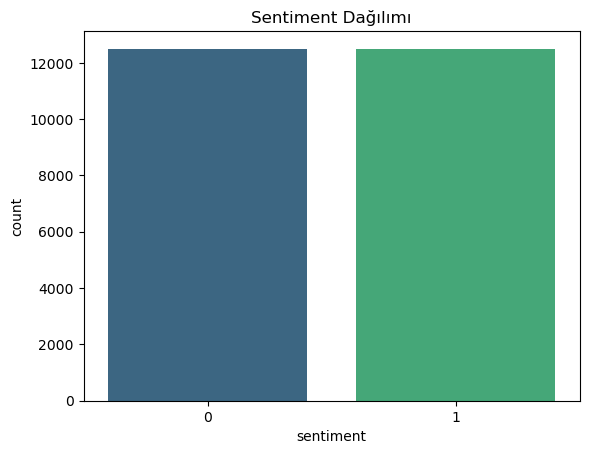

In [7]:
# Sentiment distribution
print("\n", train['sentiment'].value_counts())
sns.countplot(x='sentiment', data=train, palette='viridis')
plt.title("Sentiment Dağılımı")
plt.show()

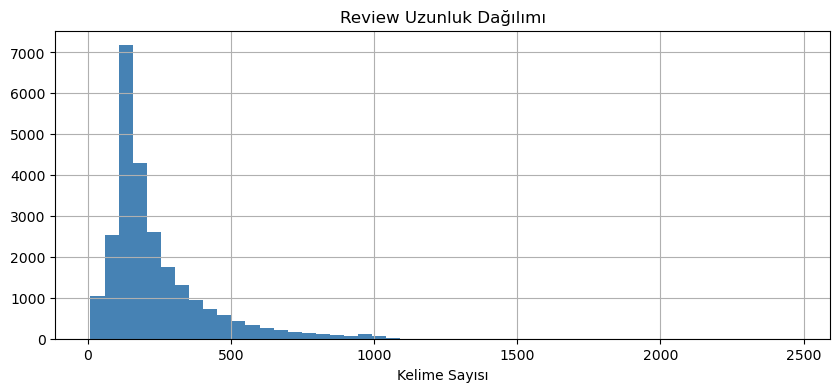

In [8]:
# Review lenght
train['review_len'] = train['review'].apply(lambda x: len(str(x).split()))
train['review_len'].hist(bins=50, figsize=(10,4), color='steelblue')
plt.title("Review Uzunluk Dağılımı")
plt.xlabel("Kelime Sayısı")
plt.show()

In [9]:
print("Ortalama uzunluk :", train['review_len'].mean())
print("Max uzunluk      :", train['review_len'].max())
print("Min uzunluk      :", train['review_len'].min())

Ortalama uzunluk : 233.78824
Max uzunluk      : 2470
Min uzunluk      : 10


In [10]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = BeautifulSoup(text, 'html.parser').get_text()  # HTML kaldır
    text = re.sub(r'[^a-zA-Z]', ' ', text)                # sadece harf
    text = text.lower()                                   # küçük harf
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]   # stopword kaldır
    return ' '.join(tokens)

train['review'] = train['review'].apply(clean_text)
unlabeled['review'] = unlabeled['review'].apply(clean_text)
test['review'] = test['review'].apply(clean_text)

In [11]:
train['review'][0]

'stuff going moment mj started listening music watching odd documentary watched wiz watched moonwalker maybe want get certain insight guy thought really cool eighties maybe make mind whether guilty innocent moonwalker part biography part feature film remember going see cinema originally released subtle messages mj feeling towards press also obvious message drugs bad kay visually impressive course michael jackson unless remotely like mj anyway going hate find boring may call mj egotist consenting making movie mj fans would say made fans true really nice actual feature film bit finally starts minutes excluding smooth criminal sequence joe pesci convincing psychopathic powerful drug lord wants mj dead bad beyond mj overheard plans nah joe pesci character ranted wanted people know supplying drugs etc dunno maybe hates mj music lots cool things like mj turning car robot whole speed demon sequence also director must patience saint came filming kiddy bad sequence usually directors hate workin

In [12]:
x = train['review']
y = train['sentiment']

In [13]:
# Train / Val split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

## TF-IDF + ML

In [14]:
#Vektorization
# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)

In [15]:
x_train_tf  = tfidf.fit_transform(x_train)
x_val_tf = tfidf.transform(x_val)
x_test_tf = tfidf.transform(test['review'])

In [16]:
modeller = {
    'BernoulliNB'              : BernoulliNB(),
    'LogisticRegression'       : LogisticRegression(),
    'DecisionTreeClassifier'   : DecisionTreeClassifier(),
    'RandomForestClassifier'   : RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'KNeighborsClassifier'     : KNeighborsClassifier(),
    'AdaBoostClassifier'       : AdaBoostClassifier(),
    'MultinomialNB'            : MultinomialNB(),
}

sonuclar = {}

for isim, model in modeller.items():
    model.fit(x_train_tf, y_train)
    tahmin = model.predict(x_val_tf)
    
    sonuclar[isim] = {
        'Accuracy' : accuracy_score(y_val, tahmin),
        'Precision': precision_score(y_val, tahmin, average='micro'),
        'Recall'   : recall_score(y_val, tahmin, average='micro'),
        'F1'       : f1_score(y_val, tahmin, average='micro'),
    }
    print(f"{isim}: {sonuclar[isim]['F1']:.4f}")

metrics = pd.DataFrame(sonuclar).T.sort_values('F1', ascending=False)
print(metrics)
print(f"\nEn iyi model: {metrics.index[0]}")

BernoulliNB: 0.8542
LogisticRegression: 0.8872
DecisionTreeClassifier: 0.7146
RandomForestClassifier: 0.8452
GradientBoostingClassifier: 0.8060
KNeighborsClassifier: 0.7914
AdaBoostClassifier: 0.7470
MultinomialNB: 0.8646
                            Accuracy  Precision  Recall      F1
LogisticRegression            0.8872     0.8872  0.8872  0.8872
MultinomialNB                 0.8646     0.8646  0.8646  0.8646
BernoulliNB                   0.8542     0.8542  0.8542  0.8542
RandomForestClassifier        0.8452     0.8452  0.8452  0.8452
GradientBoostingClassifier    0.8060     0.8060  0.8060  0.8060
KNeighborsClassifier          0.7914     0.7914  0.7914  0.7914
AdaBoostClassifier            0.7470     0.7470  0.7470  0.7470
DecisionTreeClassifier        0.7146     0.7146  0.7146  0.7146

En iyi model: LogisticRegression


              precision    recall  f1-score   support

    negative       0.90      0.87      0.89      2500
    positive       0.88      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



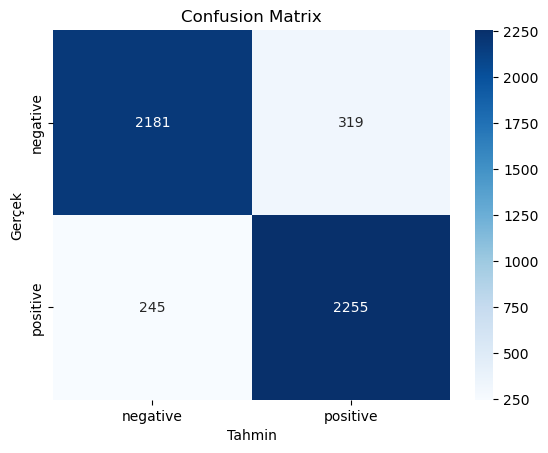

In [17]:
best_model = LogisticRegression()
best_model.fit(x_train_tf, y_train)
best_pred = best_model.predict(x_val_tf)

print(classification_report(y_val, best_pred,
      target_names=['negative', 'positive']))

cm = confusion_matrix(y_val, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','positive'],
            yticklabels=['negative','positive'])
plt.title("Confusion Matrix")
plt.ylabel("Gerçek")
plt.xlabel("Tahmin")
plt.show()

In [18]:
# En iyi model ile eğitelim
x = tfidf.fit_transform(train['review'])

best_model.fit(x, y)
final_pred = best_model.predict(x_test_tf)

# Submission
submission1 = pd.DataFrame({
    'id'       : test['id'],
    'sentiment': final_pred
})

In [19]:
submission1.head(10)

,id,sentiment
0,"""12311_10""",1
1,"""8348_2""",0
2,"""5828_4""",1
3,"""7186_2""",1
4,"""12128_7""",1
5,"""2913_8""",0
6,"""4396_1""",0
7,"""395_2""",1
8,"""10616_1""",0
9,"""9074_9""",0


In [20]:
submission1['id'] = submission1['id'].str.replace('"', '')
submission1.head()

,id,sentiment
0,12311_10,1
1,8348_2,0
2,5828_4,1
3,7186_2,1
4,12128_7,1


## Word2Vec + ML

In [21]:
#Word2Vec için tokenize edilmiş bir liste gerekli
train_sentences    = train['review'].str.split().tolist()
unlabeled_sentences = unlabeled['review'].str.split().tolist()

all_sentences = train_sentences + unlabeled_sentences

print("Toplam cümle sayısı:", len(all_sentences))
print("Örnek:", all_sentences[0][:10])

Toplam cümle sayısı: 75000
Örnek: ['stuff', 'going', 'moment', 'mj', 'started', 'listening', 'music', 'watching', 'odd', 'documentary']


In [22]:
# Word2Vec modelini eeğitelim
w2v_model = Word2Vec(
    sentences=all_sentences,
    vector_size=100,      # her kelime 100 boyutlu vektör
    window=5,             # bağlam penceresi
    min_count=2,          # en az 2 kez geçen kelimeler
    workers=4,            # paralel işlem
    epochs=10,
    sg=1                  # 1=Skip-Gram, 0=CBOW
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

In [23]:
def review_to_vector(review, model, vector_size=100):
    words  = review.split()
    # Modelde olan kelimelerin vektörlerini al
    vecs   = [model.wv[w] for w in words if w in model.wv]
    
    if len(vecs) == 0:
        return np.zeros(vector_size)   # hiç kelime yoksa sıfır vektör
    
    return np.mean(vecs, axis=0)       # ortalama vektör

# Train, val, test vektörleri
x_w2v = np.array([review_to_vector(r, w2v_model) 
                   for r in train['review']])

x_test_w2v = np.array([review_to_vector(r, w2v_model) 
                        for r in test['review']])

In [24]:
y = train['sentiment']

x_train, x_val, y_train, y_val = train_test_split(
    x_w2v, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'SVC'                : SVC(kernel='rbf', C=1.0, probability=True),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

ml_results = {}

for name, model in ml_models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_val)
    acc  = accuracy_score(y_val, pred)
    ml_results[name] = {'model': model, 'acc': acc}
    print(f"{name}: {acc:.4f}")

best_name  = max(ml_results, key=lambda k: ml_results[k]['acc'])
best_model = ml_results[best_name]['model']
best_acc   = ml_results[best_name]['acc']

print(f"\nEn iyi: {best_name} → {best_acc:.4f}")

Logistic Regression: 0.8796
SVC: 0.8840
Random Forest: 0.8496
Gradient Boosting: 0.8600

En iyi: SVC → 0.8840


              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      2500
    positive       0.88      0.89      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



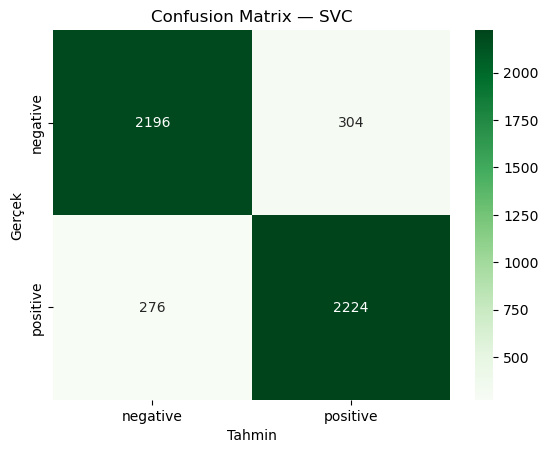

In [26]:
# Confusion Matrix
best_pred = best_model.predict(x_val)
print(classification_report(y_val, best_pred,
      target_names=['negative','positive']))

cm = confusion_matrix(y_val, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative','positive'],
            yticklabels=['negative','positive'])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Gerçek")
plt.xlabel("Tahmin")
plt.show()

In [27]:
# En iyi model ile eğitelim
best_model = SVC(kernel='rbf', C=1.0, probability=True)

best_model.fit(x_w2v, y)
final_pred = best_model.predict(x_test_w2v)

submission2 = pd.DataFrame({
    'id'       : test['id'],
    'sentiment': final_pred.astype(int)
})

submission2['id'] = submission2['id'].str.replace('"', '')

In [28]:
submission2.head(10)

,id,sentiment
0,12311_10,1
1,8348_2,0
2,5828_4,1
3,7186_2,0
4,12128_7,1
5,2913_8,1
6,4396_1,0
7,395_2,0
8,10616_1,0
9,9074_9,1


## Word2Vec + Deep Learning

In [29]:
#Tokenizer & Sequence

MAX_WORDS = 10000
MAX_LEN   = 200    # review'lar uzun olduğu için 200
EMBED_DIM = 100    # Word2Vec ile aynı boyut

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train['review'])

# Sequence'e çevir
x_seq      = tokenizer.texts_to_sequences(train['review'])
x_test_seq = tokenizer.texts_to_sequences(test['review'])

# Padding
x_pad      = pad_sequences(x_seq,      maxlen=MAX_LEN, padding='post', truncating='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')


In [30]:
# Word2Vec → Embedding Matrix
# Word2Vec ağırlıklarını Keras Embedding katmanına aktar
word_index = tokenizer.word_index

embedding_matrix = np.zeros((MAX_WORDS, EMBED_DIM))

matched   = 0
unmatched = 0

for word, idx in word_index.items():
    if idx < MAX_WORDS:
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
            matched += 1
        else:
            unmatched += 1

In [31]:
y = train['sentiment']

x_train, x_val, y_train, y_val = train_test_split(
    x_pad, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
# GlobalAveragePooling
gap_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),          # W2V ağırlıklarını dondur
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

gap_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [33]:
gap_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [34]:
#LSTM MODEL
lstm_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [35]:
#CNN 
cnn_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ ?                           │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [36]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

dl_models = {
    'GAP'  : gap_model,
    'LSTM' : lstm_model,
    'CNN'  : cnn_model
}

dl_results = {}

for name, model in dl_models.items():
    print(f"\n{'='*40}")
    print(f"🔄 Eğitiliyor: {name}")
    print(f"{'='*40}")
    
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )
    
    pred_prob = model.predict(x_val)
    pred      = (pred_prob > 0.5).astype(int).flatten()
    acc       = accuracy_score(y_val, pred)
    
    dl_results[name] = {'model': model, 'acc': acc, 'history': history}
    print(f"{name} Val Accuracy: {acc:.4f}")

# En iyi DL modeli
best_dl_name  = max(dl_results, key=lambda k: dl_results[k]['acc'])
best_dl_acc   = dl_results[best_dl_name]['acc']
print(f"En iyi DL: {best_dl_name} → {best_dl_acc:.4f}")


🔄 Eğitiliyor: GAP
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8227 - loss: 0.3950 - val_accuracy: 0.8378 - val_loss: 0.4949 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8582 - loss: 0.3352 - val_accuracy: 0.8422 - val_loss: 0.3558 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8592 - loss: 0.3247 - val_accuracy: 0.8754 - val_loss: 0.2985 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8627 - loss: 0.3245 - val_accuracy: 0.8608 - val_loss: 0.3252 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8652 - loss: 0.3175 - val_accuracy: 0.8770 - val_loss: 0.2981 - learning_rate: 0.0010
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8625 - loss: 0.3184 - val_accuracy: 0.8398 - val_loss: 0.3771 - learning_rate: 0.0010
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      2500
    positive       0.89      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



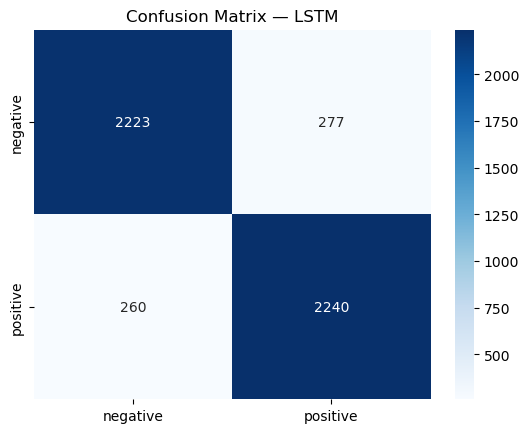

In [37]:
# Confusion Matrix - DL 
best_pred = (lstm_model.predict(x_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, best_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_val, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title("Confusion Matrix — LSTM")
plt.show()

In [38]:
# Submission
final_pred = (lstm_model.predict(x_test_pad) > 0.5).astype(int).flatten()

782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 108ms/step


In [39]:
submission = pd.DataFrame({
    'id'       : test['id'].str.replace('"', ''),
    'sentiment': final_pred
})

In [40]:
submission.head(10)

,id,sentiment
0,12311_10,1
1,8348_2,0
2,5828_4,1
3,7186_2,0
4,12128_7,1
5,2913_8,1
6,4396_1,0
7,395_2,1
8,10616_1,0
9,9074_9,1


In [41]:
submission.to_csv('submission.csv', index=False)

In [49]:
import pickle

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("✅ vectorizer.pkl kaydedildi!")
print(f"Vocabulary boyutu: {len(tfidf.vocabulary_)}")

✅ vectorizer.pkl kaydedildi!
Vocabulary boyutu: 10000


In [44]:
model.save('bagofwords_model.h5')

In [45]:
model.save('bagofwords_model.keras')

In [55]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

# Listeleri tekrar stringe çevir
train_sentences_str = [" ".join(s) if isinstance(s, list) else s for s in train_sentences]

# Doğru eğitim verisiyle yeniden fit et
tfidf_200 = TfidfVectorizer(max_features=200)
tfidf_200.fit(train_sentences_str)

print(f"Vocabulary boyutu: {len(tfidf_200.vocabulary_)}")  # 200 olmalı

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_200, f)

print("✅ vectorizer.pkl kaydedildi!")

Vocabulary boyutu: 200
✅ vectorizer.pkl kaydedildi!


Farklı derin öğrenme mimarileri (GAP, LSTM ve CNN) karşılaştırıldığında, LSTM tabanlı model en yüksek performansı göstermiş ve yaklaşık %88.9 doğruluk elde etmiştir. CNN modeli de benzer şekilde güçlü sonuçlar üretirken (~%88.2), GlobalAveragePooling (GAP) modeli nispeten daha düşük performans sergilemiştir. Word2Vec embedding’lerinin dondurularak kullanılması, modellerin dilsel örüntüleri etkili şekilde öğrenmesini sağlamıştır. Genel olarak, sıralı veri yapısını daha iyi yakalayabilen LSTM mimarisinin bu tür NLP problemlerinde daha başarılı olduğu gözlemlenmiştir.

Among the evaluated deep learning models (GAP, LSTM, and CNN), the LSTM-based model achieved the best performance with approximately 88.9% accuracy. The CNN model also delivered strong results (~88.2%), while the GlobalAveragePooling (GAP) model showed relatively lower performance. Using pre-trained Word2Vec embeddings (kept frozen) helped the models effectively capture semantic patterns. Overall, LSTM architectures proved to be more effective for this type of sequential text data.